In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os

os.getcwd()

'C:\\Users\\kezia\\Desktop\\ENVIRONMENTAL IMPACTS OF AI CAPSTONE PROECT KEZIAH AIKPO 22600200\\NOTEBOOKS'

In [3]:
import os

os.listdir("../DATA/RAW DATA SETS/Carbon intensity")

['carbon-intensity-electricity.csv']

In [4]:
df = pd.read_csv("../DATA/RAW DATA SETS/Carbon intensity/carbon-intensity-electricity.csv")

df.head()

,Entity,Code,Year,Carbon intensity of electricity per kWh,World region according to OWID
0,ASEAN (Ember),NaN,2000,572.58,NaN
1,ASEAN (Ember),NaN,2001,570.27,NaN
2,ASEAN (Ember),NaN,2002,572.68,NaN
3,ASEAN (Ember),NaN,2003,577.02,NaN
4,ASEAN (Ember),NaN,2004,583.64,NaN


In [5]:
df.shape

(6332, 5)

In [6]:
df.columns

Index(['Entity', 'Code', 'Year', 'Carbon intensity of electricity per kWh',
       'World region according to OWID'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6332 entries, 0 to 6331
Data columns (total 5 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Entity                                   6332 non-null   object 
 1   Code                                     6020 non-null   object 
 2   Year                                     6332 non-null   int64  
 3   Carbon intensity of electricity per kWh  6332 non-null   float64
 4   World region according to OWID           5717 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 247.5+ KB


In [8]:
df = df.rename(columns={
    "Carbon intensity of electricity per kWh": "Carbon_Intensity"
})

df.head()

,Entity,Code,Year,Carbon_Intensity,World region according to OWID
0,ASEAN (Ember),NaN,2000,572.58,NaN
1,ASEAN (Ember),NaN,2001,570.27,NaN
2,ASEAN (Ember),NaN,2002,572.68,NaN
3,ASEAN (Ember),NaN,2003,577.02,NaN
4,ASEAN (Ember),NaN,2004,583.64,NaN


In [9]:
df["Entity"].unique()

array(['ASEAN (Ember)', 'Afghanistan', 'Africa', 'Africa (Ember)',
       'Albania', 'Algeria', 'American Samoa', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Asia',
       'Asia (Ember)', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas',
       'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium',
       'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia',
       'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'British Virgin Islands', 'Brunei', 'Bulgaria', 'Burkina Faso',
       'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde',
       'Cayman Islands', 'Central African Republic', 'Chad', 'Chile',
       'China', 'Colombia', 'Comoros', 'Congo', 'Cook Islands',
       'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Cyprus',
       'Czechia', 'Democratic Republic of Congo', 'Denmark', 'Djibouti',
       'Dominica', 'Dominican Republic', 'EU (Ember)', 'East Timor',
       'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Eritrea',


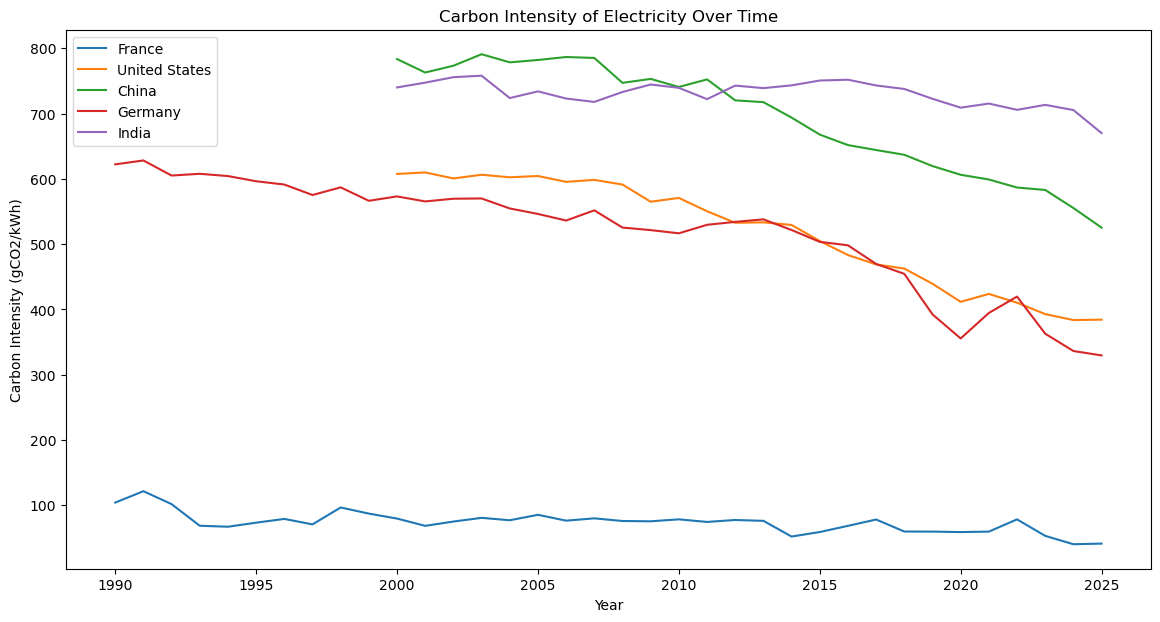

In [10]:
countries = ["France", "United States", "China", "Germany", "India"]

filtered_df = df[df["Entity"].isin(countries)]

plt.figure(figsize=(14,7))

for country in countries:
    country_data = filtered_df[filtered_df["Entity"] == country]
    
    plt.plot(
        country_data["Year"],
        country_data["Carbon_Intensity"],
        label=country
    )

plt.title("Carbon Intensity of Electricity Over Time")
plt.xlabel("Year")
plt.ylabel("Carbon Intensity (gCO2/kWh)")

plt.legend()

plt.show()

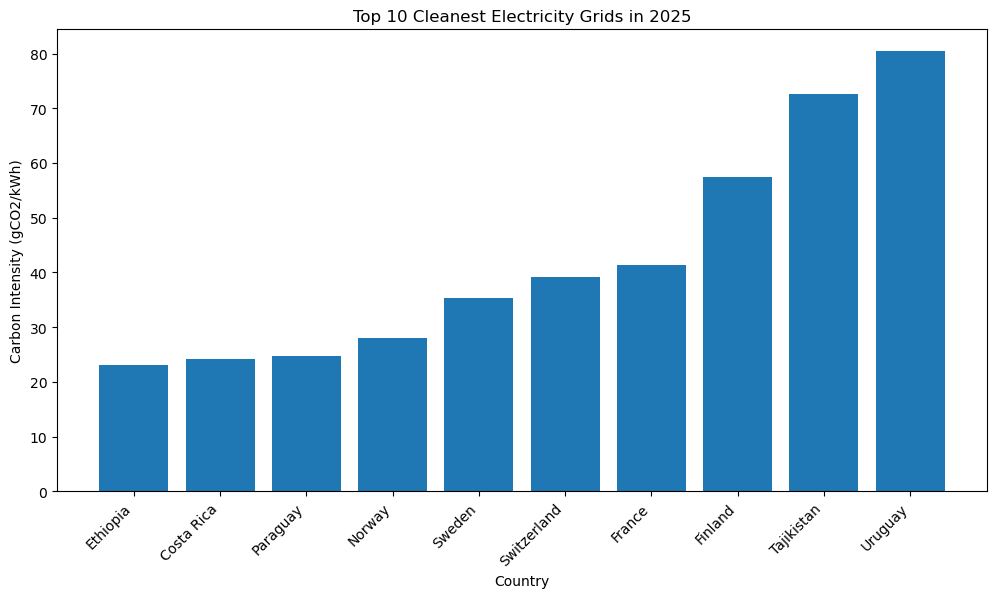

In [11]:
latest_year = 2025

cleanest_2025 = df[df["Year"] == latest_year].sort_values("Carbon_Intensity").head(10)

plt.figure(figsize=(12,6))
plt.bar(cleanest_2025["Entity"], cleanest_2025["Carbon_Intensity"])

plt.title("Top 10 Cleanest Electricity Grids in 2025")
plt.xlabel("Country")
plt.ylabel("Carbon Intensity (gCO2/kWh)")
plt.xticks(rotation=45, ha="right")

plt.show()

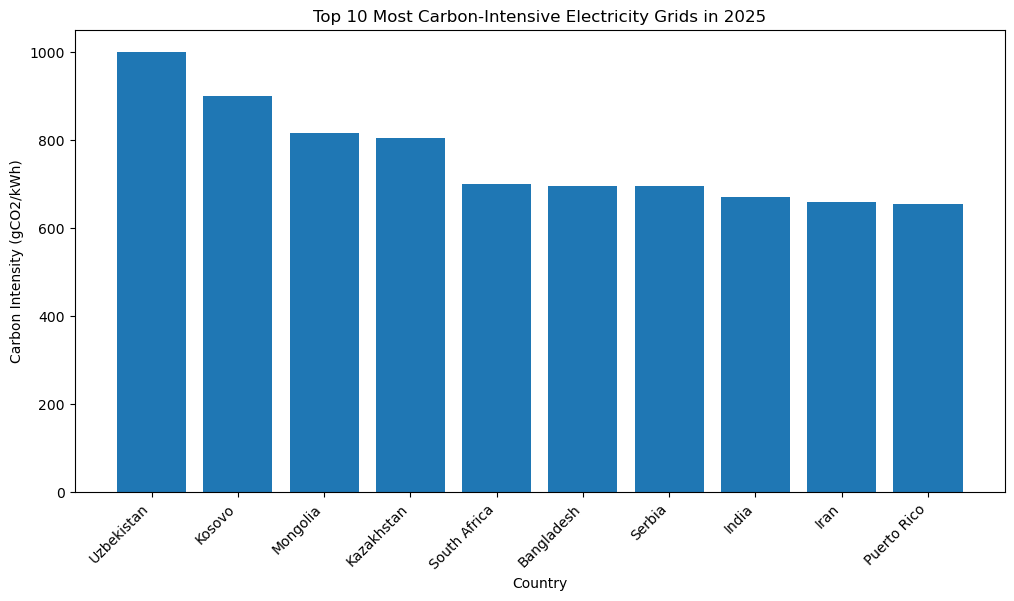

In [12]:
latest_year = 2025

dirtiest_2025 = df[df["Year"] == latest_year].sort_values("Carbon_Intensity", ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(dirtiest_2025["Entity"], dirtiest_2025["Carbon_Intensity"])

plt.title("Top 10 Most Carbon-Intensive Electricity Grids in 2025")
plt.xlabel("Country")
plt.ylabel("Carbon Intensity (gCO2/kWh)")
plt.xticks(rotation=45, ha="right")

plt.show()

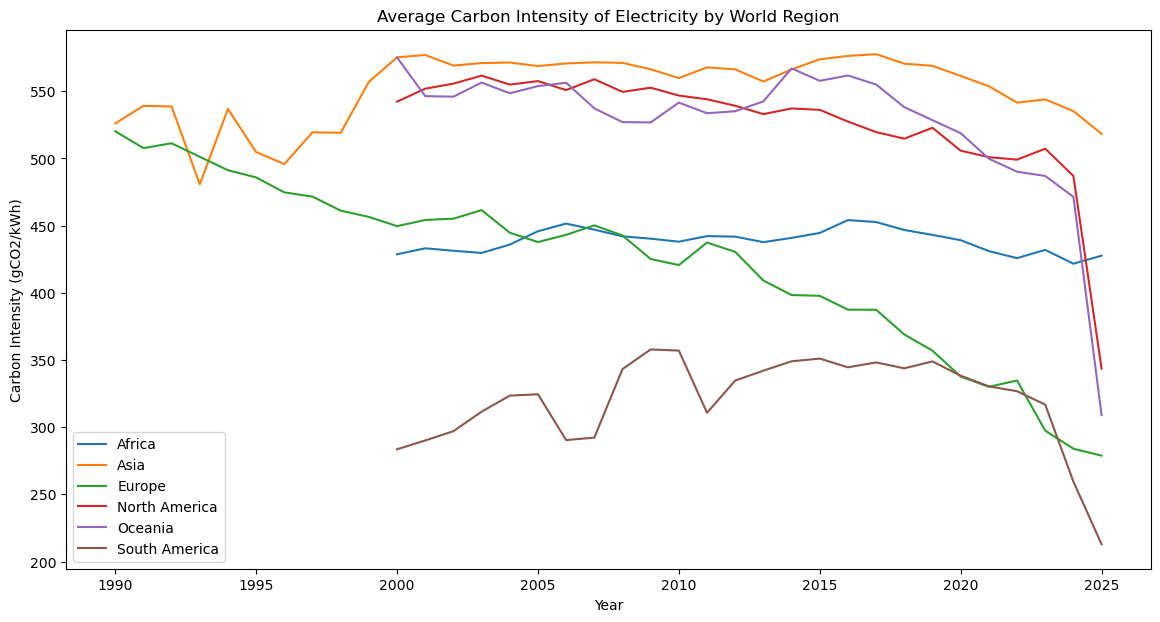

In [13]:
region_df = df.dropna(subset=["World region according to OWID"])

region_avg = (
    region_df
    .groupby(["World region according to OWID", "Year"])["Carbon_Intensity"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14,7))

for region in region_avg["World region according to OWID"].unique():
    region_data = region_avg[region_avg["World region according to OWID"] == region]
    
    plt.plot(
        region_data["Year"],
        region_data["Carbon_Intensity"],
        label=region
    )

plt.title("Average Carbon Intensity of Electricity by World Region")
plt.xlabel("Year")
plt.ylabel("Carbon Intensity (gCO2/kWh)")

plt.legend()
plt.show()

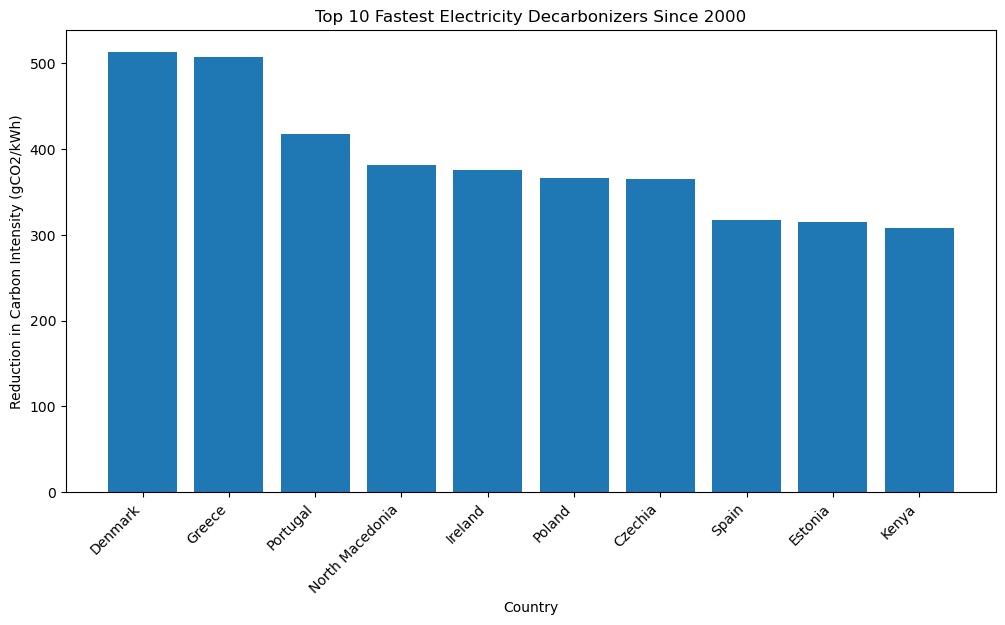

In [14]:
start_year = 2000
end_year = 2025

start_df = df[df["Year"] == start_year][["Entity", "Carbon_Intensity"]]
end_df = df[df["Year"] == end_year][["Entity", "Carbon_Intensity"]]

comparison = pd.merge(
    start_df,
    end_df,
    on="Entity",
    suffixes=("_2000", "_2025")
)

comparison["Reduction"] = (
    comparison["Carbon_Intensity_2000"] -
    comparison["Carbon_Intensity_2025"]
)

top_reducers = comparison.sort_values("Reduction", ascending=False).head(10)

plt.figure(figsize=(12,6))

plt.bar(top_reducers["Entity"], top_reducers["Reduction"])

plt.title("Top 10 Fastest Electricity Decarbonizers Since 2000")
plt.xlabel("Country")
plt.ylabel("Reduction in Carbon Intensity (gCO2/kWh)")

plt.xticks(rotation=45, ha="right")

plt.show()

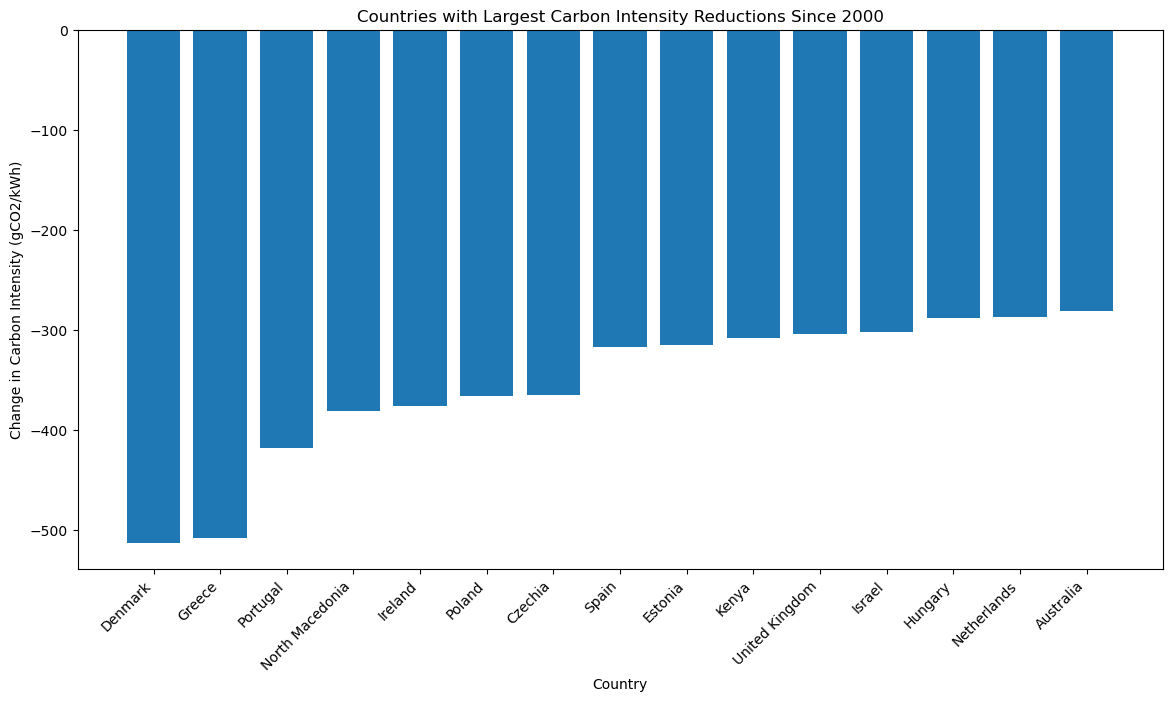

In [15]:
start_year = 2000
end_year = 2025

start_df = df[df["Year"] == start_year][["Entity", "Carbon_Intensity"]]
end_df = df[df["Year"] == end_year][["Entity", "Carbon_Intensity"]]

comparison = pd.merge(
    start_df,
    end_df,
    on="Entity",
    suffixes=("_2000", "_2025")
)

comparison["Change"] = (
    comparison["Carbon_Intensity_2025"] -
    comparison["Carbon_Intensity_2000"]
)

selected = comparison.sort_values("Change").head(15)

plt.figure(figsize=(14,7))

plt.bar(selected["Entity"], selected["Change"])

plt.title("Countries with Largest Carbon Intensity Reductions Since 2000")
plt.xlabel("Country")
plt.ylabel("Change in Carbon Intensity (gCO2/kWh)")

plt.xticks(rotation=45, ha="right")

plt.show()

In [18]:
import seaborn as sns

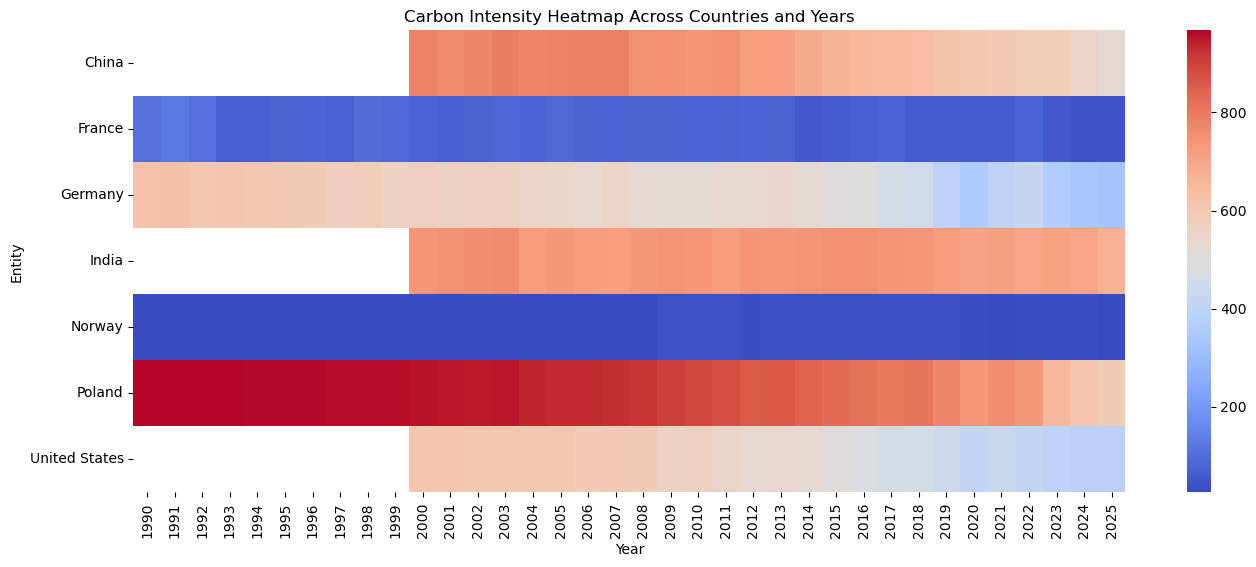

In [19]:
selected_countries = [
    "France",
    "United States",
    "China",
    "Germany",
    "India",
    "Norway",
    "Poland"
]

heatmap_df = df[df["Entity"].isin(selected_countries)]

pivot_df = heatmap_df.pivot(
    index="Entity",
    columns="Year",
    values="Carbon_Intensity"
)

plt.figure(figsize=(16,6))

sns.heatmap(pivot_df, cmap="coolwarm")

plt.title("Carbon Intensity Heatmap Across Countries and Years")

plt.show()

In [20]:
import os

os.listdir("../DATA/RAW DATA SETS/Labour Productivity")

['productivity-vs-annual-hours-worked.csv']

In [21]:
df = pd.read_csv("../DATA/RAW DATA SETS/Labour Productivity/productivity-vs-annual-hours-worked.csv")

df.head()

,Entity,Code,Year,Annual working hours per worker,Productivity: output per hour worked,Population,World region according to OWID
0,Albania,ALB,2005,2343.90,10.353054,3076156,Europe
1,Albania,ALB,2006,2333.12,11.228283,3050805,Europe
2,Albania,ALB,2007,2334.51,11.995945,3022887,Europe
3,Albania,ALB,2008,2195.57,14.754907,2992933,Europe
4,Albania,ALB,2009,2191.19,15.838745,2961487,Europe


In [22]:
df.shape

(4891, 7)

In [23]:
df.columns

Index(['Entity', 'Code', 'Year', 'Annual working hours per worker',
       'Productivity: output per hour worked', 'Population',
       'World region according to OWID'],
      dtype='object')

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4891 entries, 0 to 4890
Data columns (total 7 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Entity                                4891 non-null   object 
 1   Code                                  4891 non-null   object 
 2   Year                                  4891 non-null   int64  
 3   Annual working hours per worker       4891 non-null   float64
 4   Productivity: output per hour worked  4891 non-null   float64
 5   Population                            4891 non-null   int64  
 6   World region according to OWID        4891 non-null   object 
dtypes: float64(2), int64(2), object(3)
memory usage: 267.6+ KB


In [25]:
prod_df = df[[
    "Entity",
    "Year",
    "Productivity: output per hour worked"
]].copy()

prod_df.columns = [
    "Country",
    "Year",
    "Labour_Productivity"
]

prod_df.head()

,Country,Year,Labour_Productivity
0,Albania,2005,10.353054
1,Albania,2006,11.228283
2,Albania,2007,11.995945
3,Albania,2008,14.754907
4,Albania,2009,15.838745


In [26]:
prod_df["Country"].nunique()

129

In [27]:
prod_df["Year"].min(), prod_df["Year"].max()

(1950, 2023)

In [28]:
prod_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4891 entries, 0 to 4890
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Country              4891 non-null   object 
 1   Year                 4891 non-null   int64  
 2   Labour_Productivity  4891 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 114.8+ KB


In [29]:
prod_df.to_csv(
    "../DATA/CLEANED DATA SETS/productivity-vs-annual-hours-worked.csv",
    index=False
)

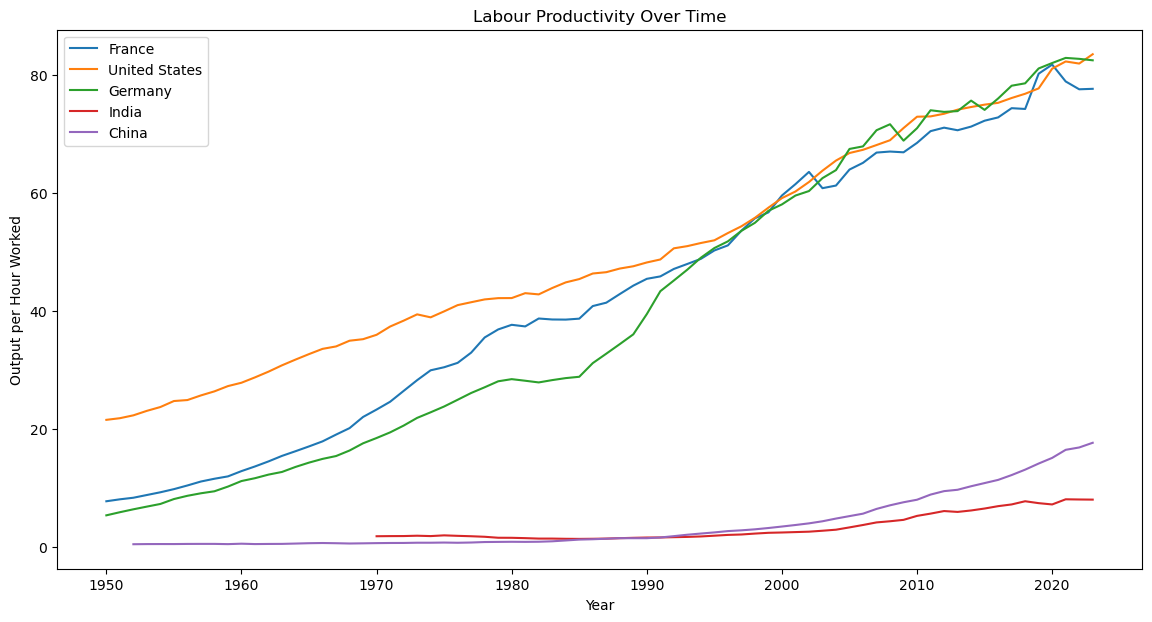

In [30]:
countries = ["France", "United States", "Germany", "India", "China"]

filtered_df = prod_df[prod_df["Country"].isin(countries)]

plt.figure(figsize=(14,7))

for country in countries:
    country_data = filtered_df[filtered_df["Country"] == country]

    plt.plot(
        country_data["Year"],
        country_data["Labour_Productivity"],
        label=country
    )

plt.title("Labour Productivity Over Time")
plt.xlabel("Year")
plt.ylabel("Output per Hour Worked")

plt.legend()
plt.show()

In [31]:
import os

os.listdir("../DATA/RAW DATA SETS/Electricity consumption")

['MES_0226.csv']

In [33]:
df = pd.read_csv(
    "../DATA/RAW DATA SETS/Electricity consumption/MES_0226.csv",
    encoding="latin1"
)

df.head()

C:\Users\kezia\AppData\Local\Temp\ipykernel_25980\1964517607.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,The Monthly electricity data explorer and the main highlights are available here: https://www.iea.org/reports/monthly-electricity-statistics-overview,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,NaN,NaN,NaN,NaN,NaN,NaN
1,Please note that your use of IEA data is subje...,NaN,NaN,NaN,NaN,NaN
2,"In particular, external dissemination of any I...",NaN,NaN,NaN,NaN,NaN
3,Please contact us at stats@iea.org if you have...,NaN,NaN,NaN,NaN,NaN
4,Last update:,12 May 2026,NaN,NaN,NaN,NaN


In [34]:
df = pd.read_csv(
    "../DATA/RAW DATA SETS/Electricity consumption/MES_0226.csv",
    encoding="latin1",
    header=None,
    low_memory=False
)

df.head(20)

,0,1,2,3,4,5
0,The Monthly electricity data explorer and the ...,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,Please note that your use of IEA data is subje...,NaN,NaN,NaN,NaN,NaN
3,"In particular, external dissemination of any I...",NaN,NaN,NaN,NaN,NaN
4,Please contact us at stats@iea.org if you have...,NaN,NaN,NaN,NaN,NaN
5,Last update:,12 May 2026,NaN,NaN,NaN,NaN
6,"This notice, and any copyright or sourcing sta...",NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN
8,Country,Time,Balance,Product,Value,Unit
9,Australia,February 2026,Net Electricity Production,Electricity,21925.7863,GWh


In [35]:
elec_df = pd.read_csv(
    "../DATA/RAW DATA SETS/Electricity consumption/MES_0226.csv",
    encoding="latin1",
    skiprows=8,
    low_memory=False
)

elec_df.head()

,Country,Time,Balance,Product,Value,Unit
0,Australia,February 2026,Net Electricity Production,Electricity,21925.7863,GWh
1,Australia,February 2026,Net Electricity Production,Hydro,937.8312,GWh
2,Australia,February 2026,Net Electricity Production,Total Combustible Fuels,12428.2915,GWh
3,Australia,February 2026,Net Electricity Production,"Coal, Peat and Manufactured Gases",8877.9572,GWh
4,Australia,February 2026,Net Electricity Production,Oil and Petroleum Products,302.4527,GWh


In [36]:
elec_df.shape
elec_df.columns
elec_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159803 entries, 0 to 159802
Data columns (total 6 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Country  159803 non-null  object 
 1   Time     159803 non-null  object 
 2   Balance  159803 non-null  object 
 3   Product  159803 non-null  object 
 4   Value    159739 non-null  float64
 5   Unit     159803 non-null  object 
dtypes: float64(1), object(5)
memory usage: 7.3+ MB


In [37]:
elec_df["Balance"].unique()

array(['Net Electricity Production', 'Used for pumped storage',
       'Distribution Losses', 'Final Consumption (Calculated)',
       'Total Imports', 'Total Exports', 'Remarks'], dtype=object)

In [38]:
elec_df["Product"].unique()

array(['Electricity', 'Hydro', 'Total Combustible Fuels',
       'Coal, Peat and Manufactured Gases', 'Oil and Petroleum Products',
       'Natural Gas', 'Combustible Renewables', 'Solar',
       'Total Renewables (Hydro, Geo, Solar, Wind, Other)', 'Wind',
       'Other Combustible Non-Renewables', 'Not Specified', 'Nuclear',
       'Geothermal', 'Data is estimated for this month',
       'Other Renewables'], dtype=object)

In [39]:
consumption_df = elec_df[
    (elec_df["Balance"] == "Final Consumption (Calculated)") &
    (elec_df["Product"] == "Electricity")
].copy()

consumption_df.head()

,Country,Time,Balance,Product,Value,Unit
11,Australia,February 2026,Final Consumption (Calculated),Electricity,20726.8164,GWh
28,Austria,February 2026,Final Consumption (Calculated),Electricity,5860.0959,GWh
46,Belgium,February 2026,Final Consumption (Calculated),Electricity,6916.2818,GWh
64,Canada,February 2026,Final Consumption (Calculated),Electricity,53648.2655,GWh
77,Chile,February 2026,Final Consumption (Calculated),Electricity,6609.8559,GWh


In [40]:
consumption_df.shape

(7968, 6)

In [41]:
consumption_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7968 entries, 11 to 159801
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  7968 non-null   object 
 1   Time     7968 non-null   object 
 2   Balance  7968 non-null   object 
 3   Product  7968 non-null   object 
 4   Value    7968 non-null   float64
 5   Unit     7968 non-null   object 
dtypes: float64(1), object(5)
memory usage: 435.8+ KB


In [42]:
consumption_df.head()

,Country,Time,Balance,Product,Value,Unit
11,Australia,February 2026,Final Consumption (Calculated),Electricity,20726.8164,GWh
28,Austria,February 2026,Final Consumption (Calculated),Electricity,5860.0959,GWh
46,Belgium,February 2026,Final Consumption (Calculated),Electricity,6916.2818,GWh
64,Canada,February 2026,Final Consumption (Calculated),Electricity,53648.2655,GWh
77,Chile,February 2026,Final Consumption (Calculated),Electricity,6609.8559,GWh


In [43]:
consumption_df["Time"].head(20)

11     February 2026
28     February 2026
46     February 2026
64     February 2026
77     February 2026
91     February 2026
105    February 2026
123    February 2026
138    February 2026
153    February 2026
170    February 2026
188    February 2026
206    February 2026
222    February 2026
239    February 2026
249    February 2026
264    February 2026
282    February 2026
300    February 2026
317    February 2026
Name: Time, dtype: object

In [44]:
consumption_df["Time"].tail(20)

159448    January 2010
159466    January 2010
159484    January 2010
159502    January 2010
159518    January 2010
159536    January 2010
159555    January 2010
159573    January 2010
159591    January 2010
159609    January 2010
159626    January 2010
159643    January 2010
159663    January 2010
159683    January 2010
159702    January 2010
159722    January 2010
159741    January 2010
159761    January 2010
159781    January 2010
159801    January 2010
Name: Time, dtype: object

In [45]:
consumption_df["Time"] = pd.to_datetime(
    consumption_df["Time"],
    format="%B %Y"
)

consumption_df.head()

,Country,Time,Balance,Product,Value,Unit
11,Australia,2026-02-01,Final Consumption (Calculated),Electricity,20726.8164,GWh
28,Austria,2026-02-01,Final Consumption (Calculated),Electricity,5860.0959,GWh
46,Belgium,2026-02-01,Final Consumption (Calculated),Electricity,6916.2818,GWh
64,Canada,2026-02-01,Final Consumption (Calculated),Electricity,53648.2655,GWh
77,Chile,2026-02-01,Final Consumption (Calculated),Electricity,6609.8559,GWh


In [46]:
consumption_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7968 entries, 11 to 159801
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Country  7968 non-null   object        
 1   Time     7968 non-null   datetime64[ns]
 2   Balance  7968 non-null   object        
 3   Product  7968 non-null   object        
 4   Value    7968 non-null   float64       
 5   Unit     7968 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 435.8+ KB


In [47]:
consumption_df["Year"] = consumption_df["Time"].dt.year

consumption_df.head()

,Country,Time,Balance,Product,Value,Unit,Year
11,Australia,2026-02-01,Final Consumption (Calculated),Electricity,20726.8164,GWh,2026
28,Austria,2026-02-01,Final Consumption (Calculated),Electricity,5860.0959,GWh,2026
46,Belgium,2026-02-01,Final Consumption (Calculated),Electricity,6916.2818,GWh,2026
64,Canada,2026-02-01,Final Consumption (Calculated),Electricity,53648.2655,GWh,2026
77,Chile,2026-02-01,Final Consumption (Calculated),Electricity,6609.8559,GWh,2026


In [48]:
annual_consumption = (
    consumption_df
    .groupby(["Country", "Year"])["Value"]
    .sum()
    .reset_index()
)

annual_consumption.columns = [
    "Country",
    "Year",
    "Electricity_Consumption"
]

annual_consumption.head()

,Country,Year,Electricity_Consumption
0,Australia,2010,220091.029
1,Australia,2011,223451.837
2,Australia,2012,222415.400
3,Australia,2013,218899.242
4,Australia,2014,225954.139


In [49]:
annual_consumption.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country                  699 non-null    object 
 1   Year                     699 non-null    int32  
 2   Electricity_Consumption  699 non-null    float64
dtypes: float64(1), int32(1), object(1)
memory usage: 13.8+ KB


In [50]:
annual_consumption.head()

,Country,Year,Electricity_Consumption
0,Australia,2010,220091.029
1,Australia,2011,223451.837
2,Australia,2012,222415.400
3,Australia,2013,218899.242
4,Australia,2014,225954.139


In [51]:
annual_consumption["Country"].nunique()

42

In [52]:
annual_consumption["Year"].min(), annual_consumption["Year"].max()

(2010, 2026)

In [53]:
annual_consumption.to_csv(
    "../DATA/CLEANED DATA SETS/electricity_consumption.csv",
    index=False
)

In [58]:
sorted(annual_consumption["Country"].unique())

['Australia',
 'Austria',
 'Belgium',
 'Canada',
 'Chile',
 'Colombia',
 'Costa Rica',
 'Czech Republic',
 'Denmark',
 'Estonia',
 'Finland',
 'France',
 'Germany',
 'Greece',
 'Hungary',
 'IEA Total',
 'Iceland',
 'Ireland',
 'Italy',
 'Japan',
 'Korea',
 'Latvia',
 'Lithuania',
 'Luxembourg',
 'Mexico',
 'Netherlands',
 'New Zealand',
 'Norway',
 'OECD Americas',
 'OECD Asia Oceania',
 'OECD Europe',
 'OECD Total',
 'Poland',
 'Portugal',
 'Republic of Turkiye',
 'Slovak Republic',
 'Slovenia',
 'Spain',
 'Sweden',
 'Switzerland',
 'United Kingdom',
 'United States']

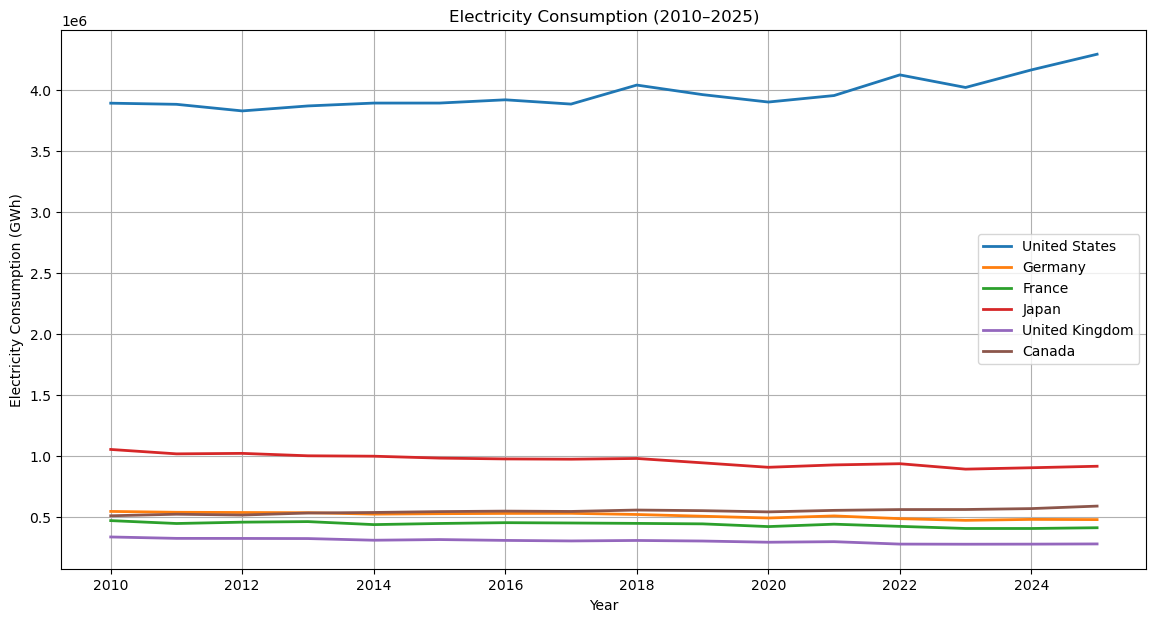

In [59]:
# Remove incomplete 2026 data
graph_df = annual_consumption[
    annual_consumption["Year"] < 2026
].copy()

countries = [
    "United States",
    "Germany",
    "France",
    "Japan",
    "United Kingdom",
    "Canada"
]

filtered_df = graph_df[
    graph_df["Country"].isin(countries)
]

plt.figure(figsize=(14,7))

for country in countries:

    country_data = filtered_df[
        filtered_df["Country"] == country
    ]

    plt.plot(
        country_data["Year"],
        country_data["Electricity_Consumption"],
        label=country,
        linewidth=2
    )

plt.title("Electricity Consumption (2010–2025)")
plt.xlabel("Year")
plt.ylabel("Electricity Consumption (GWh)")

plt.legend()
plt.grid(True)

plt.show()

In [60]:
import os

os.listdir("../DATA/RAW DATA SETS/Renewable energy share")

['API_EG.FEC.RNEW.ZS_DS2_en_csv_v2_249466.csv',
 'Metadata_Country_API_EG.FEC.RNEW.ZS_DS2_en_csv_v2_249466.csv',
 'Metadata_Indicator_API_EG.FEC.RNEW.ZS_DS2_en_csv_v2_249466.csv']

In [62]:
renew_df = pd.read_csv(
    "../DATA/RAW DATA SETS/Renewable energy share/API_EG.FEC.RNEW.ZS_DS2_en_csv_v2_249466.csv",
    skiprows=4
)

renew_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Renewable energy consumption (% of total final...,EG.FEC.RNEW.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,6.800000,8.600000,8.300000,9.10000,8.8,8.8,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Renewable energy consumption (% of total final...,EG.FEC.RNEW.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,61.426950,61.587530,62.690710,65.78238,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Renewable energy consumption (% of total final...,EG.FEC.RNEW.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,19.500000,18.300000,18.900000,18.20000,20.0,20.0,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Renewable energy consumption (% of total final...,EG.FEC.RNEW.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,76.101681,75.476578,75.078788,75.84698,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Renewable energy consumption (% of total final...,EG.FEC.RNEW.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,52.500000,52.500000,51.000000,60.10000,52.9,NaN,NaN,NaN,NaN,NaN


In [63]:
renew_df.shape
renew_df.columns
renew_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-null      flo

In [64]:
renew_clean = renew_df.drop(
    columns=[
        "Indicator Name",
        "Indicator Code",
        "Unnamed: 70"
    ]
)

renew_clean.head()

,Country Name,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Aruba,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.000000,6.800000,8.600000,8.300000,9.10000,8.8,8.8,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,61.822884,61.426950,61.587530,62.690710,65.78238,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,20.200000,19.500000,18.300000,18.900000,18.20000,20.0,20.0,NaN,NaN,NaN
3,Africa Western and Central,AFW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,75.796840,76.101681,75.476578,75.078788,75.84698,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.100000,52.500000,52.500000,51.000000,60.10000,52.9,NaN,NaN,NaN,NaN


In [65]:
renew_long = renew_clean.melt(
    id_vars=["Country Name", "Country Code"],
    var_name="Year",
    value_name="Renewable_Share"
)

renew_long.head()

,Country Name,Country Code,Year,Renewable_Share
0,Aruba,ABW,1960,NaN
1,Africa Eastern and Southern,AFE,1960,NaN
2,Afghanistan,AFG,1960,NaN
3,Africa Western and Central,AFW,1960,NaN
4,Angola,AGO,1960,NaN


In [66]:
renew_long.columns = [
    "Country",
    "Country_Code",
    "Year",
    "Renewable_Share"
]

renew_long.head()

,Country,Country_Code,Year,Renewable_Share
0,Aruba,ABW,1960,NaN
1,Africa Eastern and Southern,AFE,1960,NaN
2,Afghanistan,AFG,1960,NaN
3,Africa Western and Central,AFW,1960,NaN
4,Angola,AGO,1960,NaN


In [67]:
renew_long["Year"] = pd.to_numeric(
    renew_long["Year"],
    errors="coerce"
)

renew_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17556 entries, 0 to 17555
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          17556 non-null  object 
 1   Country_Code     17556 non-null  object 
 2   Year             17556 non-null  int64  
 3   Renewable_Share  8234 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 548.8+ KB


In [68]:
renew_long = renew_long.dropna(
    subset=["Renewable_Share"]
)

renew_long.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8234 entries, 7980 to 16752
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          8234 non-null   object 
 1   Country_Code     8234 non-null   object 
 2   Year             8234 non-null   int64  
 3   Renewable_Share  8234 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 321.6+ KB


In [69]:
renew_long.head()

,Country,Country_Code,Year,Renewable_Share
7980,Aruba,ABW,1990,0.300000
7981,Africa Eastern and Southern,AFE,1990,60.842404
7982,Afghanistan,AFG,1990,23.000000
7983,Africa Western and Central,AFW,1990,85.895442
7984,Angola,AGO,1990,72.300000


In [70]:
renew_long.shape

(8234, 4)

In [71]:
renew_long["Country"].nunique()

260

In [72]:
renew_long["Year"].min(), renew_long["Year"].max()

(1990, 2022)

In [73]:
renew_long.head(20)

,Country,Country_Code,Year,Renewable_Share
7980,Aruba,ABW,1990,0.300000
7981,Africa Eastern and Southern,AFE,1990,60.842404
7982,Afghanistan,AFG,1990,23.000000
7983,Africa Western and Central,AFW,1990,85.895442
7984,Angola,AGO,1990,72.300000
7985,Albania,ALB,1990,25.500000
7986,Andorra,AND,1990,14.100000
7987,Arab World,ARB,1990,7.556753
7988,United Arab Emirates,ARE,1990,0.000000
7989,Argentina,ARG,1990,8.600000


In [74]:
renew_long[["Country","Country_Code"]].drop_duplicates().head(30)

,Country,Country_Code
7980,Aruba,ABW
7981,Africa Eastern and Southern,AFE
7982,Afghanistan,AFG
7983,Africa Western and Central,AFW
7984,Angola,AGO
7985,Albania,ALB
7986,Andorra,AND
7987,Arab World,ARB
7988,United Arab Emirates,ARE
7989,Argentina,ARG


In [75]:
renew_long = renew_long[
    renew_long["Country_Code"].str.len() == 3
]

In [76]:
countries = [
    "United States",
    "Germany",
    "France",
    "Norway",
    "Poland",
    "Japan"
]

renew_long[
    renew_long["Country"].isin(countries)
].head()

,Country,Country_Code,Year,Renewable_Share
8035,Germany,DEU,1990,2.1
8057,France,FRA,1990,10.5
8099,Japan,JPN,1990,4.3
8157,Norway,NOR,1990,59.2
8170,Poland,POL,1990,2.5


In [77]:
renew_long[
    renew_long["Country"].str.contains("United", na=False)
]["Country"].unique()

array(['United Arab Emirates', 'United Kingdom', 'United States'],
      dtype=object)

In [78]:
renew_long[
    renew_long["Country"] == "United States"
].head()

,Country,Country_Code,Year,Renewable_Share
8231,United States,USA,1990,4.2
8497,United States,USA,1991,4.5
8763,United States,USA,1992,4.8
9029,United States,USA,1993,4.3
9295,United States,USA,1994,4.1


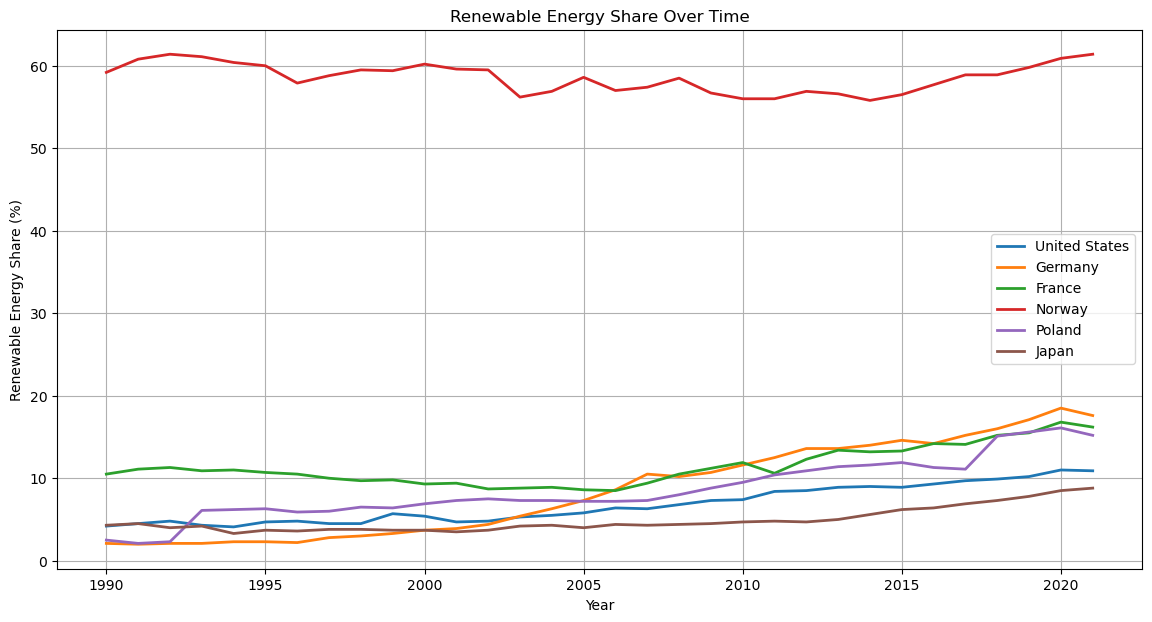

In [79]:
filtered_df = renew_long[
    renew_long["Country"].isin(countries)
]

plt.figure(figsize=(14,7))

for country in countries:
    country_data = filtered_df[
        filtered_df["Country"] == country
    ]

    plt.plot(
        country_data["Year"],
        country_data["Renewable_Share"],
        label=country,
        linewidth=2
    )

plt.title("Renewable Energy Share Over Time")
plt.xlabel("Year")
plt.ylabel("Renewable Energy Share (%)")

plt.legend()
plt.grid(True)

plt.show()

In [80]:
renew_long.to_csv(
    "../DATA/CLEANED DATA SETS/renewable_energy_share.csv",
    index=False
)

In [81]:
os.listdir("../DATA/CLEANED DATA SETS")

['AI productivity contribution',
 'Carbon emissions',
 'Carbon intensity',
 'Carbon Tax Level',
 'Datacenter Power demand',
 'Electricity consumption',
 'electricity_consumption.csv',
 'Labour Productivity',
 'productivity-vs-annual-hours-worked.csv',
 'Renewable energy share',
 'renewable_energy_share.csv',
 'Water usage']

In [83]:
import os

os.listdir("../DATA/RAW DATA SETS/Carbon intensity")

['carbon-intensity-electricity.csv']

In [84]:
carbon_df = pd.read_csv(
    "../DATA/RAW DATA SETS/Carbon intensity/carbon-intensity-electricity.csv"
)

In [85]:
carbon_df.head()

,Entity,Code,Year,Carbon intensity of electricity per kWh,World region according to OWID
0,ASEAN (Ember),NaN,2000,572.58,NaN
1,ASEAN (Ember),NaN,2001,570.27,NaN
2,ASEAN (Ember),NaN,2002,572.68,NaN
3,ASEAN (Ember),NaN,2003,577.02,NaN
4,ASEAN (Ember),NaN,2004,583.64,NaN


In [86]:
carbon_df.columns

Index(['Entity', 'Code', 'Year', 'Carbon intensity of electricity per kWh',
       'World region according to OWID'],
      dtype='object')

In [87]:
carbon_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6332 entries, 0 to 6331
Data columns (total 5 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Entity                                   6332 non-null   object 
 1   Code                                     6020 non-null   object 
 2   Year                                     6332 non-null   int64  
 3   Carbon intensity of electricity per kWh  6332 non-null   float64
 4   World region according to OWID           5717 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 247.5+ KB


In [89]:
carbon_clean = carbon_df[[
    "Entity",
    "Code",
    "Year",
    "Carbon intensity of electricity per kWh"
]].copy()

carbon_clean.columns = [
    "Country",
    "Country_Code",
    "Year",
    "Carbon_Intensity"
]

In [91]:
carbon_clean.to_csv(
    "../DATA/CLEANED DATA SETS/carbon_intensity.csv",
    index=False
)

In [92]:
os.listdir("../DATA/RAW DATA SETS/Carbon intensity")

['carbon-intensity-electricity.csv']

In [93]:
os.listdir("../DATA/CLEANED DATA SETS")

['AI productivity contribution',
 'Carbon emissions',
 'Carbon intensity',
 'Carbon Tax Level',
 'carbon_intensity.csv',
 'Datacenter Power demand',
 'Electricity consumption',
 'electricity_consumption.csv',
 'Labour Productivity',
 'productivity-vs-annual-hours-worked.csv',
 'Renewable energy share',
 'renewable_energy_share.csv',
 'Water usage']

In [95]:
os.listdir("../DATA/CLEANED DATA SETS")

['carbon_intensity.csv',
 'electricity_consumption.csv',
 'labour_productivity.csv',
 'renewable_energy_share.csv']

In [96]:
os.listdir("../DATA/RAW DATA SETS")

['AI productivity contribution not important',
 'Carbon emissions not important',
 'Carbon intensity',
 'Carbon Tax Level',
 'Datacenter Power demand',
 'Electricity consumption',
 'Labour Productivity',
 'Renewable energy share',
 'Water usage not important']

In [97]:
os.listdir("../DATA/RAW DATA SETS/Carbon Tax Level")

['carbon-tax-instruments.csv']

In [98]:
df = pd.read_csv("../DATA/RAW DATA SETS/Carbon Tax Level/carbon-tax-instruments.csv")

df.head()

,Entity,Code,Year,Covered by tax instrument in at least one sector
0,Afghanistan,AFG,1989,No carbon tax
1,Afghanistan,AFG,1990,No carbon tax
2,Afghanistan,AFG,1991,No carbon tax
3,Afghanistan,AFG,1992,No carbon tax
4,Afghanistan,AFG,1993,No carbon tax


In [100]:
os.listdir("../DATA/RAW DATA SETS/Carbon Tax Level")

['carbon-tax-instruments.csv']

In [101]:
tax_df = pd.read_csv(
    "../DATA/RAW DATA SETS/Carbon Tax Level/carbon-tax-instruments.csv"
)

In [102]:
tax_df.shape

(7437, 4)

In [103]:
tax_df.columns

Index(['Entity', 'Code', 'Year',
       'Covered by tax instrument in at least one sector'],
      dtype='object')

In [104]:
tax_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7437 entries, 0 to 7436
Data columns (total 4 columns):
 #   Column                                            Non-Null Count  Dtype 
---  ------                                            --------------  ----- 
 0   Entity                                            7437 non-null   object
 1   Code                                              7437 non-null   object
 2   Year                                              7437 non-null   int64 
 3   Covered by tax instrument in at least one sector  7437 non-null   object
dtypes: int64(1), object(3)
memory usage: 232.5+ KB


In [105]:
tax_df["Covered by tax instrument in at least one sector"].unique()

array(['No carbon tax', 'Has a carbon tax',
       'Has a carbon tax only at a sub-national level'], dtype=object)

In [107]:
tax_df["Carbon_Tax"] = tax_df[
    "Covered by tax instrument in at least one sector"
].apply(
    lambda x: 0 if x == "No carbon tax" else 1
)

In [108]:
tax_clean = tax_df[[
    "Entity",
    "Code",
    "Year",
    "Carbon_Tax"
]].copy()

tax_clean.columns = [
    "Country",
    "Country_Code",
    "Year",
    "Carbon_Tax"
]

tax_clean.head()

,Country,Country_Code,Year,Carbon_Tax
0,Afghanistan,AFG,1989,0
1,Afghanistan,AFG,1990,0
2,Afghanistan,AFG,1991,0
3,Afghanistan,AFG,1992,0
4,Afghanistan,AFG,1993,0


In [109]:
mapping = {
    "No carbon tax": 0,
    "Has a carbon tax only at a sub-national level": 1,
    "Has a carbon tax": 2
}

tax_df["Carbon_Tax_Level"] = tax_df[
    "Covered by tax instrument in at least one sector"
].map(mapping)

In [110]:
tax_clean = tax_df[[
    "Entity",
    "Code",
    "Year",
    "Carbon_Tax"
]].copy()

tax_clean.columns = [
    "Country",
    "Country_Code",
    "Year",
    "Carbon_Tax"
]

tax_clean.head()

,Country,Country_Code,Year,Carbon_Tax
0,Afghanistan,AFG,1989,0
1,Afghanistan,AFG,1990,0
2,Afghanistan,AFG,1991,0
3,Afghanistan,AFG,1992,0
4,Afghanistan,AFG,1993,0


In [111]:
tax_clean["Country"].nunique()

201

In [112]:
tax_clean["Year"].min(), tax_clean["Year"].max()

(1989, 2025)

In [113]:
tax_clean.shape

(7437, 4)

In [114]:
tax_clean.to_csv(
    "../DATA/CLEANED DATA SETS/carbon_tax.csv",
    index=False
)

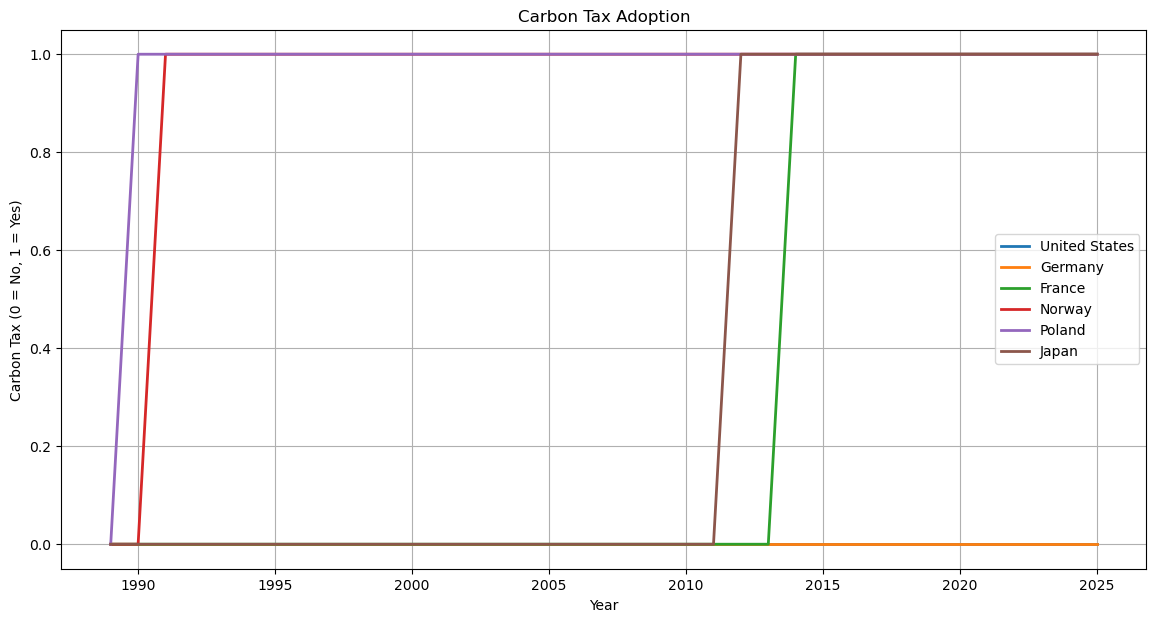

In [115]:
countries = [
    "United States",
    "Germany",
    "France",
    "Norway",
    "Poland",
    "Japan"
]

graph_df = tax_clean[
    tax_clean["Country"].isin(countries)
]

plt.figure(figsize=(14,7))

for country in countries:

    country_data = graph_df[
        graph_df["Country"] == country
    ]

    plt.plot(
        country_data["Year"],
        country_data["Carbon_Tax"],
        label=country,
        linewidth=2
    )

plt.title("Carbon Tax Adoption")
plt.xlabel("Year")
plt.ylabel("Carbon Tax (0 = No, 1 = Yes)")

plt.legend()
plt.grid(True)

plt.show()

In [116]:
os.listdir("../DATA/CLEANED DATA SETS")

['carbon_intensity.csv',
 'carbon_tax.csv',
 'electricity_consumption.csv',
 'labour_productivity.csv',
 'renewable_energy_share.csv']